In [1]:
print("om")

om


In [2]:
import os
import sys

In [3]:
# ============================================================
# Setup Project Path
# ============================================================

project_root = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..")
)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project Root:", project_root)

Project Root: c:\Users\akash\OneDrive\Documents\Qclarvoyance resources\Quantum_Protein_Ligand_Docking


In [4]:
from pathlib import Path
import sys

# Notebook is inside src/notebooks
PROJECT_ROOT = Path.cwd().parents[1]

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("Project Root :", PROJECT_ROOT)
print("Outputs      :", OUTPUTS_DIR)

Project Root : c:\Users\akash\OneDrive\Documents\Qclarvoyance resources\Quantum_Protein_Ligand_Docking
Outputs      : c:\Users\akash\OneDrive\Documents\Qclarvoyance resources\Quantum_Protein_Ligand_Docking\outputs


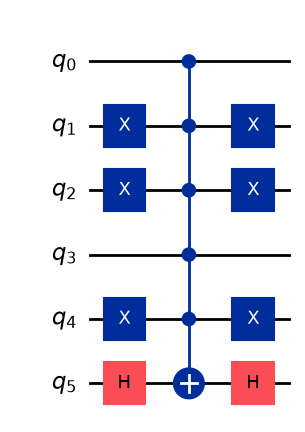

In [5]:
from src.quantum.oracle import OracleBuilder

builder = OracleBuilder()

oracle = builder.build("101001")

oracle.draw("mpl")

In [6]:
import os
import sys
import pickle

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit

from src.quantum.state_preparation import StatePreparationBuilder
from src.quantum.oracle import OracleBuilder

In [7]:
with open("../../outputs/project_data.pkl", "rb") as f:
    project_data = pickle.load(f)

In [8]:
target = ""

for bits in project_data.encoded_ligand["Encoded"]:

    target += f"{bits[0]}{bits[1]}"

print(target)

101001


In [9]:
state_builder = StatePreparationBuilder()
amp_data = project_data.amplitude_vectors[1]

print(amp_data)
qc = state_builder.prepare(amp_data)

AmplitudeData(num_qubits=6, basis_states=['101001', '000110'], indices=[41, 6], amplitude_vector=array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.70710678, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.70710678, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ]), patterns=[SearchPattern(encoded_window=((1

In [10]:
oracle = OracleBuilder().build(target)

qc.compose(oracle,inplace=True)

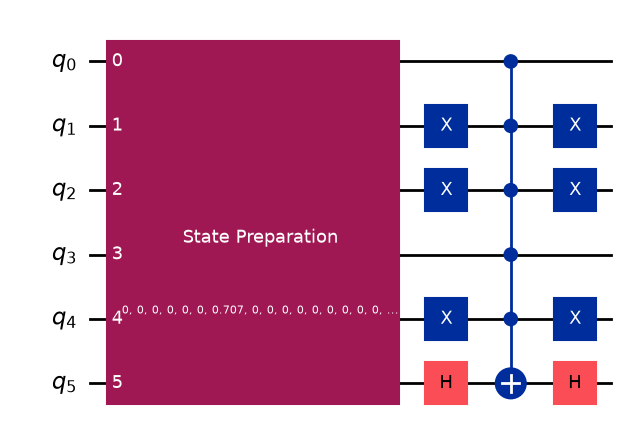

In [11]:
qc.draw("mpl")

In [12]:
oracle_state = Statevector.from_instruction(qc)

In [13]:
oracle_state

Statevector([ 1.52655666e-16+5.55111512e-16j,
              8.22557459e-31-1.87402459e-30j,
              2.34193081e-31+3.20474743e-31j,
             -3.21587050e-46+1.09476443e-47j,
              7.91033905e-16+1.17961196e-16j,
              1.75644811e-30+8.19675784e-31j,
              7.07106781e-01-1.79023463e-15j,
             -6.20337115e-15-4.44956572e-16j,
             -6.20007311e-17-5.55111512e-17j,
             -9.70744230e-17-1.32382616e-16j,
              4.74898961e-31-4.02861120e-31j,
             -2.12688282e-46-9.00144665e-48j,
              3.26345662e-32+1.53015634e-31j,
             -1.43038101e-46+5.38669119e-47j,
              1.30070718e-16+2.31096033e-18j,
             -7.34101556e-32+1.13461247e-32j,
             -6.45891615e-32-1.17906277e-31j,
             -1.92743490e-47-4.42995472e-47j,
              1.33396612e-46+1.86153352e-46j,
             -6.11906415e-62+1.33122207e-62j,
              2.67305235e-31-1.29226847e-31j,
              8.01438721e-46+3.832

In [14]:
print("State after Oracle\n")

for index, amplitude in enumerate(oracle_state.data):
    if abs(amplitude) > 1e-10:
        print(f"|{index:06b}> : {amplitude}")

State after Oracle

|000110> : (0.7071067811865483-1.7902346272080645e-15j)
|101001> : (-0.7071067811865448+1.8457457784393224e-15j)


Small example. Go to amplitude_vector.py and uncomment the line basis_states=["00"] in build() function

In [34]:
from src.quantum.amplitude_vector import  AmplitudeVectorBuilder

amp_data = AmplitudeVectorBuilder(["00"])

amp_data

In [22]:
amp = amp_data.build()

[0. 0. 0. 0.]


In [23]:
amp

AmplitudeData(num_qubits=2, basis_states=['00'], indices=[0], amplitude_vector=array([1., 0., 0., 0.]))

In [24]:
state_builder = StatePreparationBuilder()

print(amp)
qc = state_builder.prepare(amp)

AmplitudeData(num_qubits=2, basis_states=['00'], indices=[0], amplitude_vector=array([1., 0., 0., 0.]))


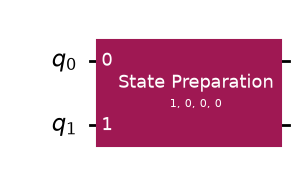

In [25]:
qc.draw("mpl")

In [26]:
target = "00"

In [27]:
oracle_state = Statevector.from_instruction(qc)

In [28]:
oracle_state.draw("latex")

<IPython.core.display.Latex object>

In [29]:
oracle = OracleBuilder().build(target)

qc.compose(oracle,inplace=True)


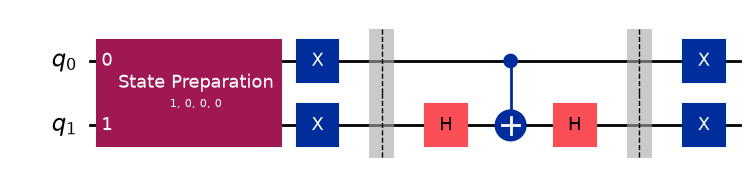

In [30]:
qc.draw("mpl")

In [31]:
oracle_state = Statevector.from_instruction(qc)

In [32]:
oracle_state

Statevector([-1.00000000e+00+0.j,  0.00000000e+00+0.j,  2.23711432e-17+0.j,
              0.00000000e+00+0.j],
            dims=(2, 2))


In [33]:
print("State after Oracle\n")

for index, amplitude in enumerate(oracle_state.data):
    if abs(amplitude) > 1e-10:
        print(f"|{index:02b}> : {amplitude}")

State after Oracle

|00> : (-0.9999999999999998+0j)
